# Reproducing the observation

What we want is to have a simulator that is able to reproduce the outputs of Observation 5 with different values of the turbulent power spectrum. We keep the emissivity field, binning and everything else fixed.

We start with the imports

In [1]:
# Classics
import matplotlib.pyplot as plt
from astropy.io import fits
import jax.numpy as jnp
import cmasher as cmr
import jax
import xarray as xr
import numpy as np

# Astropy
from astropy.cosmology import LambdaCDM
cosmo = LambdaCDM(H0 = 70, Om0 = 0.3, Ode0 = 0.7)

from fast_turbulence_sim.simulation import rng_key, Simulation
from fast_turbulence_sim.binning import LoadBinning
from fast_turbulence_sim.grid import SpatialGrid3D
from fast_turbulence_sim.structure_function import StructureFunction
from fast_turbulence_sim.projection import Projection

#Progress bar (fancy)
from tqdm.notebook import tqdm as tqdm_notebook

Define the spatial grid

In [2]:
# Pixel size 
pixsize_m = 317e-6 # 317 um
focal_length = 12 # 12 m
pixsize_arcmin = pixsize_m/focal_length * 180 / jnp.pi * 60
pixsize_kpc = pixsize_arcmin * cosmo.kpc_proper_per_arcmin(0.1).value

# Spatial grid
spatial_grid = SpatialGrid3D(pixsize=pixsize_kpc, 
                             shape=(232,232), 
                             los_factor=5)
print('The pixel size in kiloparsecs is {:.2f} kpc'.format(pixsize_kpc))

The pixel size in kiloparsecs is 10.05 kpc


Load the emissivity cube used for emission-weighting (see corresponding notebook for the creation of said cube)

In [3]:
# Emissivity cube
em = jnp.load('/Users/amolin/Documents/Code/DataOlympe/molin/data_newxifu/emissivity_cube_19p_newxifu_novign.npy')

Load the binning used for Observation 5 and define SF

In [4]:
# Load binning
binning = LoadBinning(shape = (232,232),
                 binning_file = '/Users/amolin/Documents/Code/DataNUWA/XIFUHome/xifu_cluster_sim/clusters/cluster_1_corr/cluster_1_repeat_1/19p_mosaic/region_dict.p',
                 count_map_file = '/Users/amolin/Documents/Code/DataNUWA/XIFUHome/xifu_cluster_sim/clusters/cluster_1_corr/cluster_1_repeat_1/19p_mosaic/count_map.fits')

# Get values from binning
X_pixels, Y_pixels, bin_num_pix, nb_bins, xBar_bins, yBar_bins, bin_nb_map = binning()

# Load structure function
sf = StructureFunction(bins = jnp.geomspace(3,200,20))

Load the fits file defining the instrument PSF and to normalize it to one

In [5]:
sf = StructureFunction(bins=jnp.geomspace(3, 200, 20))
PSF_kernel = jnp.array(fits.getdata('/Users/amolin/Documents/Code/DataOlympe/molin/data_newxifu/PSF_image.fits'),
                       dtype='float64')
PSF_kernel *= 1 / jnp.sum(PSF_kernel)
PSF_kernel_zero_padded = jnp.pad(PSF_kernel, pad_width=int((232 - 58) / 2), mode='edge')

Load the measurement error

In [6]:
data_mes_err = jnp.load('/Users/amolin/Documents/Code/DataOlympe/molin/data_newxifu/Obs5_bkg/mes_err_stats.npz')
radial_bins_mes_errors = jnp.array(data_mes_err['radial_bins_mes_errors'], dtype = 'float32')
censhift_offsets       = jnp.array(data_mes_err['censhift_offsets'], dtype = 'float32')
censhift_errors        = jnp.array(data_mes_err['censhift_errors'], dtype = 'float32')
broad_offsets          = jnp.array(data_mes_err['broad_offsets'], dtype = 'float32')
broad_errors           = jnp.array(data_mes_err['broad_errors'], dtype = 'float32')

## Define the simulator

In [7]:
#Projection
projection = Projection(binning, em, PSF_kernel_zero_padded)

# Simulation
sim = Simulation(spatial_grid,
                                    sf,
                                    binning,
                                    projection,
                                    radial_bins_mes_errors,
                                    censhift_offsets,
                                    censhift_errors,
                                    broad_offsets,
                                    broad_errors)

Now that the simulator is defined, we use jax.jit to speedup the computation

In [8]:
@jax.jit
def run_sim(rng_key : jax.random.PRNGKey,
                 sigma : float,
                 log_inj : float,
                 log_dis : float,
                 alpha : float):

    return sim(rng_key,
               sigma,
                 log_inj ,
                 log_dis,
                 alpha )

Check one realization

In [9]:
%%time
sigma = 250
log_inj = jnp.log10(300)
log_dis = jnp.log10(1e-3)
alpha = 11/3
rng_key = jax.random.PRNGKey(12)

dist, sf, sf_std, v_vec, std_vec = run_sim(rng_key, sigma, log_inj, log_dis, alpha)
dist.block_until_ready()

CPU times: user 9.9 s, sys: 1.05 s, total: 11 s
Wall time: 5.96 s


Array([  3.43127793,   4.19342926,   5.28089055,   6.54794827,
         8.17852947,  10.20300117,  12.74476743,  15.91153414,
        19.74894859,  24.63311876,  30.78361378,  38.27975871,
        47.74393349,  59.50107445,  74.19237662,  91.70513915,
       113.7190896 , 140.85664956, 168.76054278], dtype=float64)

Look at the binned velocity field

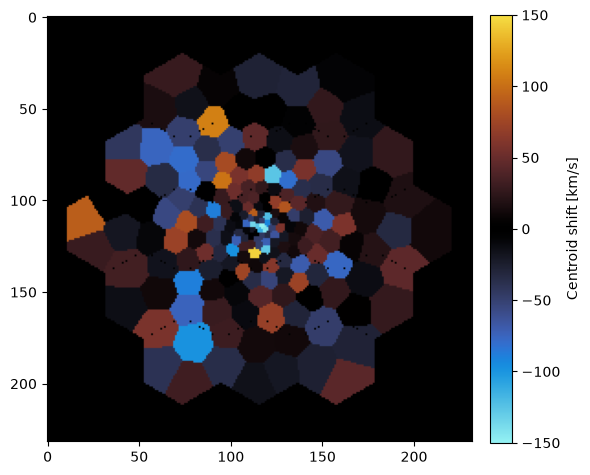

In [10]:
binned_censhift_output = jnp.zeros((232,232))
binned_censhift_output = binned_censhift_output.at[X_pixels, Y_pixels].set(v_vec[bin_num_pix])
fig,ax = plt.subplots(1,1, figsize = (6,6))

im =ax.imshow(binned_censhift_output, cmap = cmr.iceburn, vmin = -150, vmax = 150)
plt.colorbar(im, pad = 0.04, fraction = 0.046, label = 'Centroid shift [km/s]')

Look at the structure function

Text(0, 0.5, 'Centroid shift SF [km2/s2]')

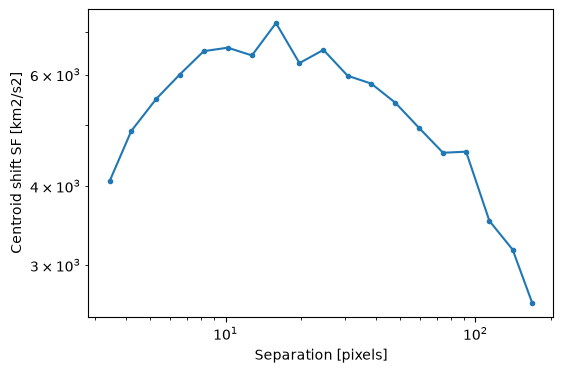

In [11]:
fig, ax = plt.subplots(1,1, figsize = (6,4))

ax.loglog(dist, sf, marker ='.')
#ax[0].loglog(dists, sf_censhift_inp+2*std_diff_censhift**2, label = r'Output + $2\sigma^2$', marker ='.', color = 'tab:blue', alpha = 0.5, ls = '--')
ax.set_xlabel('Separation [pixels]')
ax.set_ylabel('Centroid shift SF [km2/s2]')


Check that on average, the simulator outputs something around the observation used as a reference 

In [12]:
Nsims = 100
SFs_censhift = jnp.zeros((Nsims,19))
SFs_broad = jnp.zeros((Nsims,19))
vecs_censhift = jnp.zeros((Nsims,nb_bins))
vecs_broad = jnp.zeros((Nsims,nb_bins))


for k in tqdm_notebook(np.arange(Nsims), total = Nsims, desc=''):
    #Create key
    rng_key = jax.random.PRNGKey(np.random.randint(1e6))

    #Call function
    dist, sf, sf_std, v_vec, std_vec = run_sim(rng_key,
                                               sigma,
                                               log_inj,
                                               log_dis,
                                               alpha)
    # Set values
    SFs_censhift = SFs_censhift.at[k].set(sf)
    SFs_broad = SFs_broad.at[k].set(sf_std)
    vecs_censhift = vecs_censhift.at[k].set(v_vec)
    vecs_broad = vecs_broad.at[k].set(std_vec)

  0%|          | 0/100 [00:00<?, ?it/s]

In [13]:
SFs_real = xr.open_dataset("../../data/XIFU_Observation5/outputs_SFs.nc")

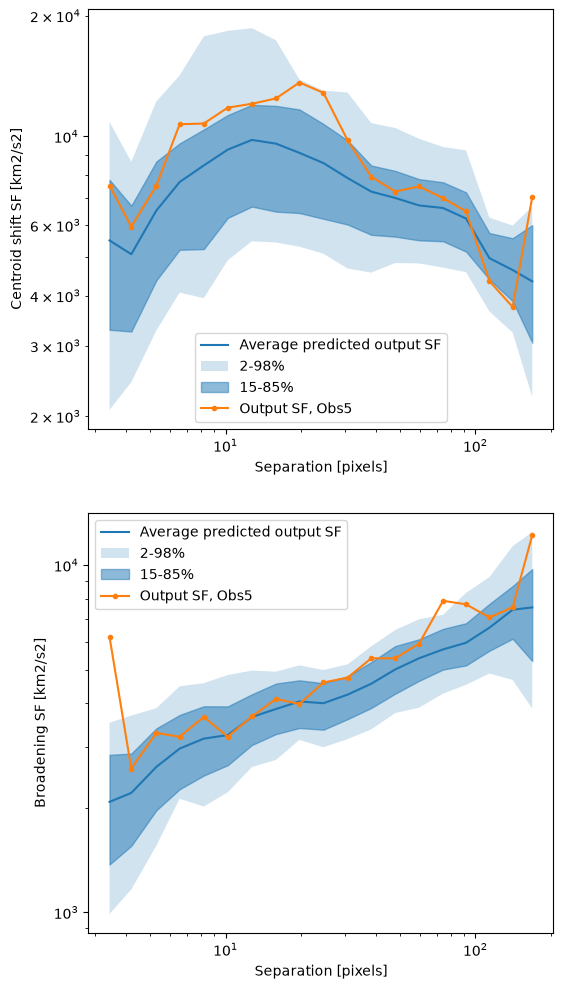

In [14]:
fig, ax = plt.subplots(2,1, figsize = (6,12))

ax[0].loglog(dist, jnp.mean(SFs_censhift, axis =0),
            label = 'Average predicted output SF')

ax[0].fill_between(dist, 
                   jnp.percentile(SFs_censhift, 2, axis = 0),
                   jnp.percentile(SFs_censhift, 98, axis = 0),
                   alpha = 0.2,
                   label = '2-98%'
                  )

ax[0].fill_between(dist, 
                   jnp.percentile(SFs_censhift, 15, axis = 0),
                   jnp.percentile(SFs_censhift, 85, axis = 0),
                   alpha = 0.5,
                   color = 'tab:blue',
                   label = '15-85%')

ax[1].loglog(dist, jnp.mean(SFs_broad, axis =0),
            label = 'Average predicted output SF')

ax[1].fill_between(dist, 
                   jnp.percentile(SFs_broad, 2, axis = 0),
                   jnp.percentile(SFs_broad, 98, axis = 0),
                   alpha = 0.2,
                   label = '2-98%')

ax[1].fill_between(dist, 
                   jnp.percentile(SFs_broad, 15, axis = 0),
                   jnp.percentile(SFs_broad, 85, axis = 0),
                   alpha = 0.5,
                   color = 'tab:blue',
                   label = '15-85%')

#ax[0].loglog(dist, sf, label = 'Input ', marker ='.')

ax[0].loglog(dist, 
             SFs_real.sel(SF = 'CentroidShift').to_array()[0], 
             label = 'Output SF, Obs5', marker ='.')

#ax[0].loglog(dists_obs2, sf_censhift_inp_obs2, label = 'Input Obs 2', marker ='.')
#ax[0].loglog(dists, sf_censhift_out, label = 'Output', marker ='.')

ax[0].set_xlabel('Separation [pixels]')
ax[0].set_ylabel('Centroid shift SF [km2/s2]')
ax[0].legend()
#ax[0].set_ylim(2e2, 5e4)

ax[1].loglog(dist, 
             SFs_real.sel(SF = 'Broadening').to_array()[0], 
             label = 'Output SF, Obs5', marker ='.')
#ax[1].loglog(dists, sf_broad_inp_obs2, label = 'Input Obs 2', marker ='.')
ax[1].set_xlabel('Separation [pixels]')
ax[1].set_ylabel('Broadening SF [km2/s2]')
ax[1].legend()
#ax[1].set_ylim(1e2, 5e3)